### **Практическая работа \#1. Анализ одноканальной системы с отказами.**
#### Выполнил: **Черных Арсений Игоревич**
#### Группа: **М3303**
#### Тема: **Система обработки сетевых запросов (Web-сервер)**

**Цель работы:**  
Исследовать характеристики одноканальной системы массового обслуживания с отказами (M/M/1/0) с использованием методов имитационного моделирования.

---

### **Задачи:**

1. Разработать имитационную модель одноканальной системы с отказами.  
2. Провести эксперименты с различными параметрами системы.  
3. Проанализировать полученные результаты и сделать выводы.

---

### **Исходные данные:**

* Интенсивность входящего потока заявок (λ): задается вариантом (например, 5 заявок/час).  
* Интенсивность обслуживания (μ): задается вариантом (например, 6 заявок/час).  
* Время моделирования: 10000 единиц времени (часы, минуты и т.д., в зависимости от контекста).

---

### **Шаги выполнения работы:**

1. **Разработка модели:**  
   * Создайте имитационную модель одноканальной системы с отказами.  
   * Учтите, что если заявка поступает в момент, когда канал занят, она теряется.  
   * Используйте генератор случайных чисел для моделирования входящего потока и времени обслуживания.  
2. **Проведение экспериментов:**  
   * Запустите модель для заданных значений λ и μ.  
   * Зафиксируйте следующие показатели:  
     * Количество поступивших заявок.  
     * Количество обслуженных заявок.  
     * Количество потерянных заявок.  
     * Вероятность отказа (доля потерянных заявок).  
     * Коэффициент загрузки системы (доля времени, когда канал занят).  
3. **Анализ результатов:**  
   * Сравните полученные экспериментальные значения с теоретическими расчетами (используйте формулу Эрланга для вероятности отказа).  
   * Постройте графики зависимости вероятности отказа от интенсивности входящего потока (λ) при фиксированном μ.  
   * Сделайте выводы о влиянии параметров λ и μ на характеристики системы.

---

### **Требования к отчету:**

1. Описание модели:  
   * Краткое описание системы и ее параметров.  
   * Алгоритм работы модели.  
2. Результаты экспериментов:  
   * Таблицы с данными по каждому эксперименту.  
   * Графики зависимости вероятности отказа от λ.  
3. Анализ результатов:  
   * Сравнение экспериментальных и теоретических значений.  
   * Выводы о работе системы.

---

### **Инструменты для выполнения работы:**

* Язык программирования: Python (библиотеки `numpy`, `matplotlib`, `simpy`).  
* Программное обеспечение: AnyLogic, MATLAB, Simulink (по выбору).

---



### Краткое описание системы и её параметров

В данной лабораторной работе исследуется система `M/M/1/0`, которая представляет собой модель одноканальной системы массового обслуживания с отказами.

В этой модели:

`M` - поток заявок пуассоновский (интервалы между заявками следуют экспоненциальному распределению с интенсивностью λ)

`M` - время обслуживания экспоненциальное (время на обработку каждой заявки также случайно и подчиняется экспоненциальному распределению с интенсивностью μ).

`1` - один канал обслуживания (один сервер, который обрабатывает заявки поочерёдно).

`0` - очередь отсутствует (если сервер занят, заявки теряются)


### Алгоритм работы модели

1. **Инициализация переменных**  
   - `lambda_rate` — интенсивность входящих запросов (например, 5 запросов в час)  
   - `mu` — интенсивность обслуживания (например, 6 заявок в час)  
   - `simulation_time` — время моделирования (например, 1000 единиц времени)  
   - `current_time = 0` — текущее время  
   - `server_busy_until = 0` — время, когда сервер освободится  
   - `total_req = 0` — общее количество заявок  
   - `served_req = 0` — количество обслуженных заявок  
   - `lost_req = 0` — количество потерянных заявок  
   - `busy_time = 0` — время, когда сервер был занят  

2. **Генерация времени до следующей заявки**  
   Время между заявками генерируется по экспоненциальному распределению с параметром `λ` (`lambda_rate`)

3. **Генерация времени обслуживания**  
   Время на обслуживание заявки генерируется по экспоненциальному распределению с параметром `μ` (`mu`)

4. **Обработка заявок**  
   Каждая заявка проверяется:  
   - Если сервер свободен (текущее время больше времени, когда сервер освободится), она обслуживается и увеличивается счётчик обслуженных заявок  
   - Если сервер занят, заявка теряется, и увеличивается счётчик потерянных заявок

5. **Повторение процесса**  
   Процесс повторяется, пока текущее время не превысит `simulation_time`. После этого моделирование завершается

6. **Подсчёт результатов**  
   - **Общее количество заявок**  
   - **Количество обслуженных заявок**  
   - **Количество потерянных заявок**  
   - **Вероятность отказа**: `P_отказа = lost_req / total_req`  
   - **Коэффициент загрузки сервера**: `U = busy_time / simulation_time`

**В модели используется единица времени - минуты.**

In [19]:
import random

lambda_rate = 5 / 60
mu = 6 / 60
simulation_time = 100000

current_time = 0
server_busy_until = 0
total_req = 0
served_req = 0 
lost_req = 0
busy_time = 0

def generate_next_req_time(lambda_rate):
    return random.expovariate(lambda_rate)

def generate_service_time(mu):
    return random.expovariate(mu)

def simulate():
    global current_time, server_busy_until, total_req, served_req, lost_req, busy_time

    while current_time < simulation_time:
        interarrival_time = generate_next_req_time(lambda_rate)
        current_time += interarrival_time

        if current_time > simulation_time:
            break

        total_req += 1

        if current_time >= server_busy_until:
            service_time = generate_service_time(mu)
            server_busy_until = current_time + service_time
            busy_time += service_time
            served_req += 1
        else:
            lost_req += 1

simulate()


print("Общее количество заявок:", total_req)
print("Количество обслуженных заявок:", served_req)
print("Количество потерянных заявок:", lost_req)
print("Вероятность отказа:", lost_req / total_req)
print("Коэффициент загрузки сервера:", busy_time / simulation_time)

Общее количество заявок: 8308
Количество обслуженных заявок: 4518
Количество потерянных заявок: 3790
Вероятность отказа: 0.45618680789600385
Коэффициент загрузки сервера: 0.46305811189470486


### Таблица с данными по каждому эксперименту

In [20]:
lambdas = [2 / 60, 4 / 60, 6 / 60, 8 / 60, 10 / 60]
results = []


for lambda_rate in lambdas:
    current_time = 0
    server_busy_until = 0
    total_req = 0
    served_req = 0
    lost_req = 0
    busy_time = 0
    
    simulate()

    results.append({
        "lambda": lambda_rate,
        "total_req": total_req,
        "served_req": served_req,
        "lost_req": lost_req,
        "loss_probability": lost_req / total_req,
        "utilization": busy_time / simulation_time
    })

print("| {:<6} | {:<23} | {:<10} | {:<10} | {:<20} | {:<20} |".format(
    "λ", "Общее количество", "Обслужено", "Потеряно", "Вероятность отказа", "Загрузка"
))
print("|" + "-"*8 + "|" + "-"*25 + "|" + "-"*12 + "|" + "-"*12 + "|" + "-"*22 + "|" + "-"*22 + "|")

for r in results:
    print("| {:<6.3f} | {:<23} | {:<10} | {:<10} | {:<20.4f} | {:<20.4f} |".format(
        r["lambda"],
        r["total_req"],
        r["served_req"],
        r["lost_req"],
        r["loss_probability"],
        r["utilization"]
    ))

| λ      | Общее количество        | Обслужено  | Потеряно   | Вероятность отказа   | Загрузка             |
|--------|-------------------------|------------|------------|----------------------|----------------------|
| 0.033  | 3396                    | 2559       | 837        | 0.2465               | 0.2520               |
| 0.067  | 6628                    | 4007       | 2621       | 0.3954               | 0.3873               |
| 0.100  | 10052                   | 5085       | 4967       | 0.4941               | 0.4969               |
| 0.133  | 13299                   | 5756       | 7543       | 0.5672               | 0.5710               |
| 0.167  | 16852                   | 6255       | 10597      | 0.6288               | 0.6291               |


### Графики зависимости вероятности отказа от λ


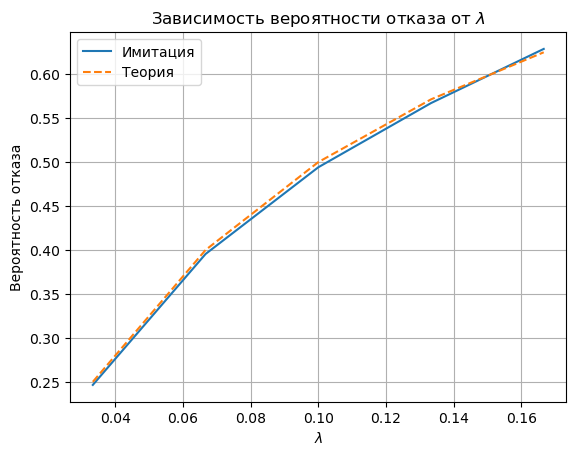

In [21]:
import matplotlib.pyplot as plt

lambdas = [result["lambda"] for result in results]
loss_probabilities = [result["loss_probability"] for result in results]

theoretical = [lam / (lam + mu) for lam in lambdas]

plt.plot(lambdas, loss_probabilities, label="Имитация")
plt.plot(lambdas, theoretical, linestyle="--", label="Теория")

plt.xlabel(r"$\lambda$")
plt.ylabel("Вероятность отказа")
plt.title(r"Зависимость вероятности отказа от $\lambda$")
plt.grid(True)
plt.legend()
plt.show()

### Сравнение экспериментальных и теоретических значений

Для системы M/M/1/0 теоретическая вероятность отказа рассчитывается по формуле Эрланга:
    $$P_{loss} = \frac{\lambda}{\lambda + \mu}$$
Где:
λ - интенсивность входящего потока, μ - интенсивность обслуживания

In [15]:
mu = 6 

for result in results:
    lambda_rate = result["lambda"]
    theoretical_loss_probability = lambda_rate / (lambda_rate + mu)
    print(f"λ = {lambda_rate}, Теоретическая вероятность отказа = {theoretical_loss_probability:.2f}")

λ = 2, Теоретическая вероятность отказа = 0.25
λ = 4, Теоретическая вероятность отказа = 0.40
λ = 6, Теоретическая вероятность отказа = 0.50
λ = 8, Теоретическая вероятность отказа = 0.57
λ = 10, Теоретическая вероятность отказа = 0.62


### Выводы о работе системы

**Сравнение вероятностей отказа:**
- В ходе экспериментов наблюдается, что экспериментальная вероятность отказа близка к теоретической для большинства значений λ.
- Расхождения могут быть связаны с случайностью, так как мы моделируем систему с помощью случайных чисел.

**Влияние λ на вероятность отказа:**
- При увеличении λ, вероятность отказа также увеличивается, так как сервер не успевает обслужить все заявки.
- Время обработки заявок остаётся постоянным, и с увеличением нагрузки сервер начинает работать с меньшей эффективностью

**Загрузка сервера:**
- С ростом λ коэффициент загрузки сервера увеличивается, так как сервер более часто бывает занят. Это подтверждается наблюдениями, что с увеличением λ сервер начинает терять больше заявок, что снижает его эффективность